In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (13910, 131)


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V121,V122,V123,V124,V125,V126,V127,V128,V129,Class
0,1,12285.6582,4.076635,4.842317,7.509393,10.822436,-1.312657,-1.853717,-6.924985,11800.9233,...,1784.5324,1.907000,1.729200,4.881194,8.623828,-0.314110,-0.661556,-3.521663,10.0,4
1,2,-35.6889,0.993944,0.166099,0.489363,3.484663,-0.130298,-0.528364,-3.735347,266.4145,...,904.9898,1.433707,1.068069,2.532958,5.369720,-0.183779,-0.534087,-4.635975,50.0,3
2,3,63927.2217,14.956941,19.971376,29.188512,33.291320,-10.433776,-16.062245,-49.490143,57405.8483,...,14585.7879,8.189021,6.099452,12.127991,15.709651,-3.887082,-6.731473,-19.326895,250.0,4
3,4,2992.9019,1.380553,0.808910,1.288259,4.660135,-0.755903,-1.120470,-4.075213,4301.4033,...,6044.5554,3.488295,2.662288,5.938297,8.544508,-1.567322,-2.701235,-6.472439,600.0,3
4,5,57524.7812,11.912566,14.631496,19.809240,23.715868,-9.084750,-11.770585,-39.234003,50051.0703,...,10580.1006,5.752675,3.880740,8.545897,11.831716,-2.655521,-4.312744,-8.510591,150.0,4


In [4]:
y = df["Class"].values        # labela (samo za evaluaciju)
X_raw = df.drop(columns=["Class"])

print("X shape:", X_raw.shape)
print("y shape:", y.shape)
print("Broj klasa:", np.unique(y).size)

X shape: (13910, 130)
y shape: (13910,)
Broj klasa: 6


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Custom flowsom


In [15]:
# Bibliotecki FlowSOM

In [12]:
pd.DataFrame(clusters, columns=["cluster"]).to_csv(
    "../results/flowsom_clusters_full.csv", index=False
)
print("✅ Sačuvano: results/flowsom_clusters_full.csv")

✅ Sačuvano: results/flowsom_clusters_full.csv


In [13]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Napomena: klasterovanje je urađeno nad X_pca, pa je fer da interne metrike računamo nad X_pca
sil = silhouette_score(X_pca, clusters)
db  = davies_bouldin_score(X_pca, clusters)

# Eksterne metrike (samo za evaluaciju)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

sil, db, ari, nmi

(np.float64(0.4050506421854778),
 np.float64(1.1621651105754187),
 0.02951575702488785,
 np.float64(0.13552262529446446))

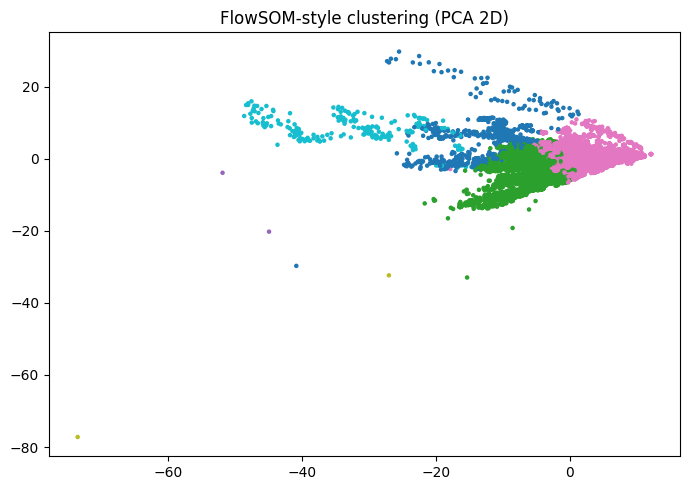

In [14]:
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, s=5, cmap="tab10")
plt.title("FlowSOM-style clustering (PCA 2D)")
plt.tight_layout()
plt.show()